In [1]:
import numpy as np 
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
true_df=pd.read_csv("True.csv")
fake_df=pd.read_csv("Fake.csv")

# EDA

In [3]:
true_df.head()

,title,text,subject,date
0,"As U.S. budget fight looms, Republicans flip t...",WASHINGTON (Reuters) - The head of a conservat...,politicsNews,"December 31, 2017"
1,U.S. military to accept transgender recruits o...,WASHINGTON (Reuters) - Transgender people will...,politicsNews,"December 29, 2017"
2,Senior U.S. Republican senator: 'Let Mr. Muell...,WASHINGTON (Reuters) - The special counsel inv...,politicsNews,"December 31, 2017"
3,FBI Russia probe helped by Australian diplomat...,WASHINGTON (Reuters) - Trump campaign adviser ...,politicsNews,"December 30, 2017"
4,Trump wants Postal Service to charge 'much mor...,SEATTLE/WASHINGTON (Reuters) - President Donal...,politicsNews,"December 29, 2017"


In [4]:
fake_df.head()

,title,text,subject,date
0,Donald Trump Sends Out Embarrassing New Year’...,Donald Trump just couldn t wish all Americans ...,News,"December 31, 2017"
1,Drunk Bragging Trump Staffer Started Russian ...,House Intelligence Committee Chairman Devin Nu...,News,"December 31, 2017"
2,Sheriff David Clarke Becomes An Internet Joke...,"On Friday, it was revealed that former Milwauk...",News,"December 30, 2017"
3,Trump Is So Obsessed He Even Has Obama’s Name...,"On Christmas day, Donald Trump announced that ...",News,"December 29, 2017"
4,Pope Francis Just Called Out Donald Trump Dur...,Pope Francis used his annual Christmas Day mes...,News,"December 25, 2017"


In [5]:
print("Fake news:", fake_df.shape)
print("True news:", true_df.shape)

Fake news: (23481, 4)
True news: (21417, 4)


In [6]:
print("Fake news columns:")
print(fake_df.columns)

print("\nTrue news columns:")
print(true_df.columns)

Fake news columns:
Index(['title', 'text', 'subject', 'date'], dtype='str')

True news columns:
Index(['title', 'text', 'subject', 'date'], dtype='str')


In [7]:
print(fake_df.isnull().sum())

title      0
text       0
subject    0
date       0
dtype: int64


In [8]:
print(true_df.isnull().sum())

title      0
text       0
subject    0
date       0
dtype: int64


In [9]:
fake_df["label"] = 0
true_df["label"] = 1

In [10]:
df = pd.concat([fake_df, true_df], ignore_index=True)

In [11]:
df.head()

,title,text,subject,date,label
0,Donald Trump Sends Out Embarrassing New Year’...,Donald Trump just couldn t wish all Americans ...,News,"December 31, 2017",0
1,Drunk Bragging Trump Staffer Started Russian ...,House Intelligence Committee Chairman Devin Nu...,News,"December 31, 2017",0
2,Sheriff David Clarke Becomes An Internet Joke...,"On Friday, it was revealed that former Milwauk...",News,"December 30, 2017",0
3,Trump Is So Obsessed He Even Has Obama’s Name...,"On Christmas day, Donald Trump announced that ...",News,"December 29, 2017",0
4,Pope Francis Just Called Out Donald Trump Dur...,Pope Francis used his annual Christmas Day mes...,News,"December 25, 2017",0


In [12]:
df.shape

(44898, 5)

In [13]:
df = df.sample(frac=1, random_state=42).reset_index(drop=True)

In [14]:
df.head()

,title,text,subject,date,label
0,Ben Stein Calls Out 9th Circuit Court: Committ...,"21st Century Wire says Ben Stein, reputable pr...",US_News,"February 13, 2017",0
1,Trump drops Steve Bannon from National Securit...,WASHINGTON (Reuters) - U.S. President Donald T...,politicsNews,"April 5, 2017",1
2,Puerto Rico expects U.S. to lift Jones Act shi...,(Reuters) - Puerto Rico Governor Ricardo Rosse...,politicsNews,"September 27, 2017",1
3,OOPS: Trump Just Accidentally Confirmed He Le...,"On Monday, Donald Trump once again embarrassed...",News,"May 22, 2017",0
4,Donald Trump heads for Scotland to reopen a go...,"GLASGOW, Scotland (Reuters) - Most U.S. presid...",politicsNews,"June 24, 2016",1


In [15]:
df["label"].value_counts()

label
0    23481
1    21417
Name: count, dtype: int64

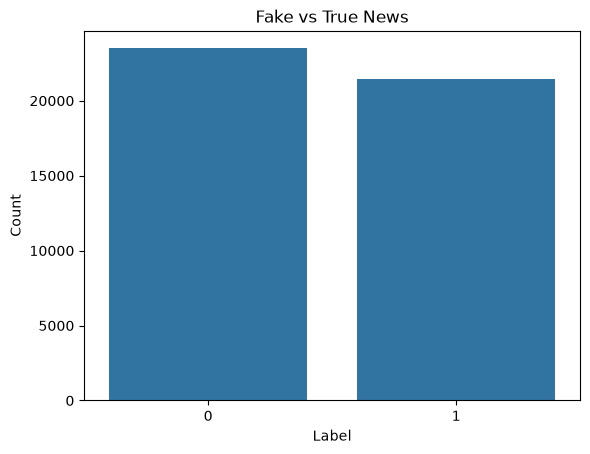

In [16]:
sns.countplot(x="label", data=df)

plt.title("Fake vs True News")
plt.xlabel("Label")
plt.ylabel("Count")
plt.show()

In [17]:
df.duplicated().sum()

np.int64(209)

In [18]:
df = df.drop_duplicates()

In [19]:
df.duplicated().sum()

np.int64(0)

In [20]:
df.shape

(44689, 5)

In [21]:
df.isnull().sum()

title      0
text       0
subject    0
date       0
label      0
dtype: int64

In [22]:
df["text_length"] = df["text"].astype(str).apply(len)

In [23]:
df["text_length"].describe()

count    44689.000000
mean      2467.098682
std       2173.612347
min          1.000000
25%       1232.000000
50%       2185.000000
75%       3101.000000
max      51794.000000
Name: text_length, dtype: float64

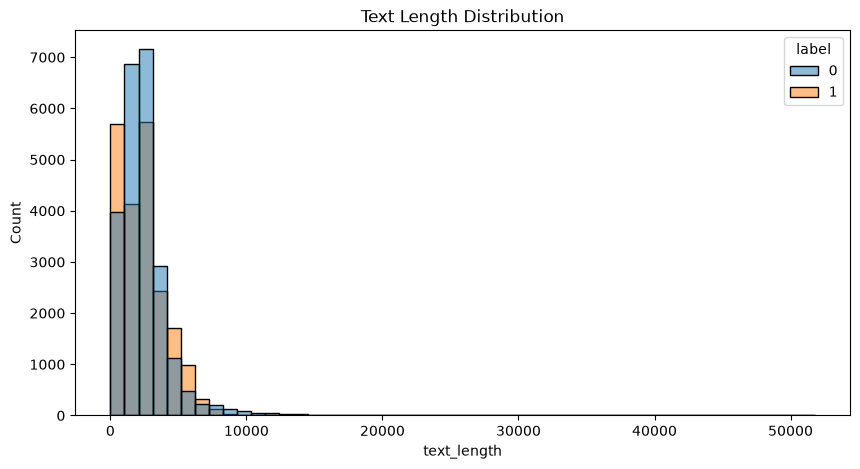

In [24]:
plt.figure(figsize=(10, 5))

sns.histplot(
    data=df,
    x="text_length",
    hue="label",
    bins=50
)

plt.title("Text Length Distribution")
plt.show()

In [25]:
df["subject"].value_counts()

subject
politicsNews       11220
worldnews           9991
News                9050
politics            6838
left-news           4459
Government News     1570
US_News              783
Middle-east          778
Name: count, dtype: int64

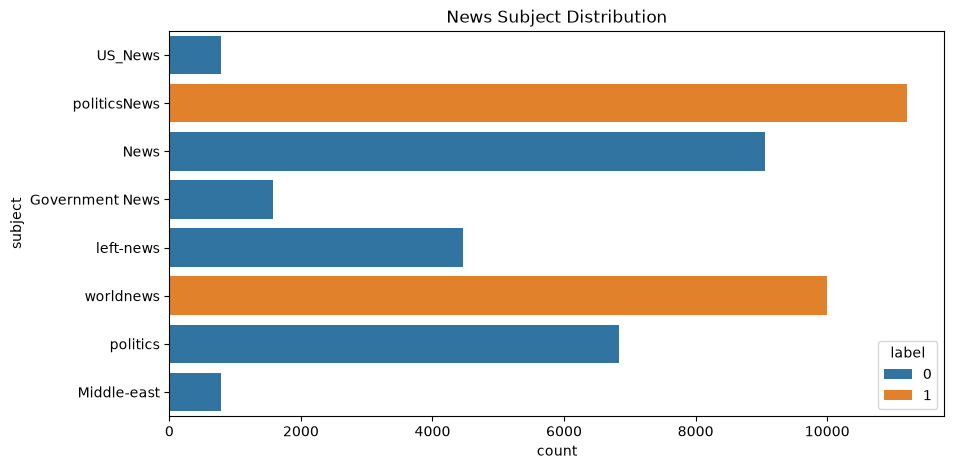

In [26]:
plt.figure(figsize=(10, 5))

sns.countplot(
    data=df,
    y="subject",
    hue="label"
)

plt.title("News Subject Distribution")
plt.show()

In [27]:
df.shape

(44689, 6)

# Text Preprocessing

In [28]:
print(df["text"].iloc[0])

21st Century Wire says Ben Stein, reputable professor from, Pepperdine University (also of some Hollywood fame appearing in TV shows and films such as Ferris Bueller s Day Off) made some provocative statements on Judge Jeanine Pirro s show recently. While discussing the halt that was imposed on President Trump s Executive Order on travel. Stein referred to the judgement by the 9th Circuit Court in Washington state as a  Coup d tat against the executive branch and against the constitution.  Stein went on to call the Judges in Seattle  political puppets  and the judiciary  political pawns. Watch the interview below for the complete statements and note the stark contrast to the rhetoric of the leftist media and pundits who neglect to note that no court has ever blocked any Presidential orders in immigration in the past or discuss the legal efficacy of the halt or the actual text of the Executive Order.READ MORE TRUMP NEWS AT: 21st Century Wire Trump FilesSUPPORT OUR WORK BY SUBSCRIBING & 

In [34]:
import re
import string

In [35]:
def clean_text(text):
    text = str(text)
    
    # Convert to lowercase
    text = text.lower()
    
    # Remove URLs
    text = re.sub(r'http\S+|www\S+', '', text)

    # Remove HTML tags
    text = re.sub(r'<.*?>', '', text)

    # Remove @ mentions
    text = re.sub(r'@\S+', '', text)

    # Remove punctuation
    text = text.translate(
        str.maketrans(string.punctuation, ' ' * len(string.punctuation))
    )
    
    # Remove extra spaces
    text = re.sub(r'\s+', ' ', text).strip()
    
    return text

In [36]:
sample = df["text"].iloc[0]

print("BEFORE:\n")
print(sample)

print("\nAFTER:\n")
print(clean_text(sample))

BEFORE:

21st Century Wire says Ben Stein, reputable professor from, Pepperdine University (also of some Hollywood fame appearing in TV shows and films such as Ferris Bueller s Day Off) made some provocative statements on Judge Jeanine Pirro s show recently. While discussing the halt that was imposed on President Trump s Executive Order on travel. Stein referred to the judgement by the 9th Circuit Court in Washington state as a  Coup d tat against the executive branch and against the constitution.  Stein went on to call the Judges in Seattle  political puppets  and the judiciary  political pawns. Watch the interview below for the complete statements and note the stark contrast to the rhetoric of the leftist media and pundits who neglect to note that no court has ever blocked any Presidential orders in immigration in the past or discuss the legal efficacy of the halt or the actual text of the Executive Order.READ MORE TRUMP NEWS AT: 21st Century Wire Trump FilesSUPPORT OUR WORK BY SUBSC

In [37]:
import string

In [38]:
print(string.punctuation)

!"#$%&'()*+,-./:;<=>?@[\]^_`{|}~


In [39]:
import nltk

In [40]:
nltk.download("punkt")

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\Madhur\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!


True

In [41]:
nltk.download("punkt_tab")

[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\Madhur\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


True

In [42]:
print(df.columns)

Index(['title', 'text', 'subject', 'date', 'label', 'text_length'], dtype='str')


In [43]:
df["clean_text"] = df["text"].apply(clean_text)

In [44]:
print(df.columns)

Index(['title', 'text', 'subject', 'date', 'label', 'text_length',
       'clean_text'],
      dtype='str')


In [45]:
from nltk.tokenize import word_tokenize

df["tokens"] = df["clean_text"].apply(word_tokenize)

In [46]:
print(df[["clean_text", "tokens"]].head())

                                          clean_text  \
0  21st century wire says ben stein reputable pro...   
1  washington reuters u s president donald trump ...   
2  reuters puerto rico governor ricardo rossello ...   
3  on monday donald trump once again embarrassed ...   
4  glasgow scotland reuters most u s presidential...   

                                              tokens  
0  [21st, century, wire, says, ben, stein, reputa...  
1  [washington, reuters, u, s, president, donald,...  
2  [reuters, puerto, rico, governor, ricardo, ros...  
3  [on, monday, donald, trump, once, again, embar...  
4  [glasgow, scotland, reuters, most, u, s, presi...  


In [47]:
nltk.download("stopwords")

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\Madhur\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [48]:
from nltk.corpus import stopwords

stop_words = set(stopwords.words("english"))

In [49]:
print(list(stop_words)[:30])

["she's", 'until', 'above', "i'll", 'ours', "she'd", 'while', 'about', 'ourselves', 'were', 'more', 'her', 'him', 'can', 'me', 'on', "they're", 'an', 'between', "we'll", 'your', 'now', 'in', 'before', 'has', 'down', 'a', 'during', 'it', "i'm"]


In [50]:
def remove_stopwords(tokens):
    return [word for word in tokens if word not in stop_words]

In [51]:
sample_tokens = df["tokens"].iloc[0]

filtered_tokens = remove_stopwords(sample_tokens)

print("Before:")
print(sample_tokens[:30])

print("\nAfter:")
print(filtered_tokens[:30])

Before:
['21st', 'century', 'wire', 'says', 'ben', 'stein', 'reputable', 'professor', 'from', 'pepperdine', 'university', 'also', 'of', 'some', 'hollywood', 'fame', 'appearing', 'in', 'tv', 'shows', 'and', 'films', 'such', 'as', 'ferris', 'bueller', 's', 'day', 'off', 'made']

After:
['21st', 'century', 'wire', 'says', 'ben', 'stein', 'reputable', 'professor', 'pepperdine', 'university', 'also', 'hollywood', 'fame', 'appearing', 'tv', 'shows', 'films', 'ferris', 'bueller', 'day', 'made', 'provocative', 'statements', 'judge', 'jeanine', 'pirro', 'show', 'recently', 'discussing', 'halt']


In [52]:
df["filtered_tokens"] = df["tokens"].apply(remove_stopwords)

In [53]:
print(df[["tokens", "filtered_tokens"]].head())

                                              tokens  \
0  [21st, century, wire, says, ben, stein, reputa...   
1  [washington, reuters, u, s, president, donald,...   
2  [reuters, puerto, rico, governor, ricardo, ros...   
3  [on, monday, donald, trump, once, again, embar...   
4  [glasgow, scotland, reuters, most, u, s, presi...   

                                     filtered_tokens  
0  [21st, century, wire, says, ben, stein, reputa...  
1  [washington, reuters, u, president, donald, tr...  
2  [reuters, puerto, rico, governor, ricardo, ros...  
3  [monday, donald, trump, embarrassed, country, ...  
4  [glasgow, scotland, reuters, u, presidential, ...  


In [54]:
from nltk.stem import PorterStemmer

stemmer = PorterStemmer()

words = ["playing", "played", "plays", "studies", "running"]

for word in words:
    print(word, "→", stemmer.stem(word))

playing → play
played → play
plays → play
studies → studi
running → run


In [55]:
from nltk.stem import WordNetLemmatizer

nltk.download("wordnet")
nltk.download("omw-1.4")

lemmatizer = WordNetLemmatizer()

for word in words:
    print(word, "→", lemmatizer.lemmatize(word, pos="v"))

[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\Madhur\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to
[nltk_data]     C:\Users\Madhur\AppData\Roaming\nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


playing → play
played → play
plays → play
studies → study
running → run


In [56]:
def lemmatize_tokens(tokens):
    return [lemmatizer.lemmatize(word) for word in tokens]

In [57]:
df["lemmatized_tokens"] = df["filtered_tokens"].apply(lemmatize_tokens)

In [58]:
df["final_text"] = df["lemmatized_tokens"].apply(lambda x: " ".join(x))

In [59]:
print(df["final_text"].iloc[0])

21st century wire say ben stein reputable professor pepperdine university also hollywood fame appearing tv show film ferris bueller day made provocative statement judge jeanine pirro show recently discussing halt imposed president trump executive order travel stein referred judgement 9th circuit court washington state coup tat executive branch constitution stein went call judge seattle political puppet judiciary political pawn watch interview complete statement note stark contrast rhetoric leftist medium pundit neglect note court ever blocked presidential order immigration past discus legal efficacy halt actual text executive order read trump news 21st century wire trump filessupport work subscribing becoming member


In [60]:
print(df[["title", "final_text", "label"]].head())

                                               title  \
0  Ben Stein Calls Out 9th Circuit Court: Committ...   
1  Trump drops Steve Bannon from National Securit...   
2  Puerto Rico expects U.S. to lift Jones Act shi...   
3   OOPS: Trump Just Accidentally Confirmed He Le...   
4  Donald Trump heads for Scotland to reopen a go...   

                                          final_text  label  
0  21st century wire say ben stein reputable prof...      0  
1  washington reuters u president donald trump re...      1  
2  reuters puerto rico governor ricardo rossello ...      1  
3  monday donald trump embarrassed country accide...      0  
4  glasgow scotland reuters u presidential candid...      1  


In [61]:
print(df["final_text"].isnull().sum())

0


In [62]:
df["model_text"] = df["title"].fillna("") + " " + df["final_text"].fillna("")

In [63]:
print(df["model_text"].iloc[0])

Ben Stein Calls Out 9th Circuit Court: Committed a ‘Coup d’état’ Against the Constitution 21st century wire say ben stein reputable professor pepperdine university also hollywood fame appearing tv show film ferris bueller day made provocative statement judge jeanine pirro show recently discussing halt imposed president trump executive order travel stein referred judgement 9th circuit court washington state coup tat executive branch constitution stein went call judge seattle political puppet judiciary political pawn watch interview complete statement note stark contrast rhetoric leftist medium pundit neglect note court ever blocked presidential order immigration past discus legal efficacy halt actual text executive order read trump news 21st century wire trump filessupport work subscribing becoming member


In [64]:
df["clean_title"] = df["title"].apply(clean_text)

In [65]:
print(df["clean_title"].iloc[0])

ben stein calls out 9th circuit court committed a ‘coup d’état’ against the constitution


In [66]:
df["title_tokens"] = df["clean_title"].apply(word_tokenize)

df["title_filtered"] = df["title_tokens"].apply(remove_stopwords)

df["title_lemmatized"] = df["title_filtered"].apply(lemmatize_tokens)

In [67]:
df["clean_title_final"] = df["title_lemmatized"].apply(
    lambda x: " ".join(x)
)

In [68]:
print(df["clean_title_final"].iloc[0])

ben stein call 9th circuit court committed ‘ coup ’ état ’ constitution


In [69]:
df["model_text"] = (
    df["clean_title_final"] + " " + df["final_text"]
)

In [70]:
print(df["model_text"].iloc[0])

ben stein call 9th circuit court committed ‘ coup ’ état ’ constitution 21st century wire say ben stein reputable professor pepperdine university also hollywood fame appearing tv show film ferris bueller day made provocative statement judge jeanine pirro show recently discussing halt imposed president trump executive order travel stein referred judgement 9th circuit court washington state coup tat executive branch constitution stein went call judge seattle political puppet judiciary political pawn watch interview complete statement note stark contrast rhetoric leftist medium pundit neglect note court ever blocked presidential order immigration past discus legal efficacy halt actual text executive order read trump news 21st century wire trump filessupport work subscribing becoming member


In [71]:
from sklearn.model_selection import train_test_split

X = df["model_text"]
y = df["label"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [72]:
from sklearn.feature_extraction.text import TfidfVectorizer

In [73]:
tfidf = TfidfVectorizer(
    max_features=50000
)

In [74]:
X_train_tfidf = tfidf.fit_transform(X_train)

In [75]:
X_test_tfidf = tfidf.transform(X_test)

In [76]:
print("X_train:", X_train_tfidf.shape)
print("X_test :", X_test_tfidf.shape)

X_train: (35751, 50000)
X_test : (8938, 50000)


In [77]:
from sklearn.linear_model import LogisticRegression
lr = LogisticRegression(
    max_iter=1000,
    random_state=42
)
lr.fit(X_train_tfidf, y_train)
y_pred_lr = lr.predict(X_test_tfidf)
print(y_pred_lr[:20])

[1 1 1 0 1 0 0 0 0 1 0 0 1 1 0 1 1 0 0 0]


In [78]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

In [79]:
print("Accuracy :", accuracy_score(y_test, y_pred_lr))
print("Precision:", precision_score(y_test, y_pred_lr))
print("Recall   :", recall_score(y_test, y_pred_lr))
print("F1 Score :", f1_score(y_test, y_pred_lr))

Accuracy : 0.9879167599015439
Precision: 0.9833956969130028
Recall   : 0.9912776991984913
F1 Score : 0.9873209673632308


In [80]:
print(classification_report(y_test, y_pred_lr))

              precision    recall  f1-score   support

           0       0.99      0.98      0.99      4696
           1       0.98      0.99      0.99      4242

    accuracy                           0.99      8938
   macro avg       0.99      0.99      0.99      8938
weighted avg       0.99      0.99      0.99      8938



In [81]:
cm = confusion_matrix(y_test, y_pred_lr)

print(cm)

[[4625   71]
 [  37 4205]]


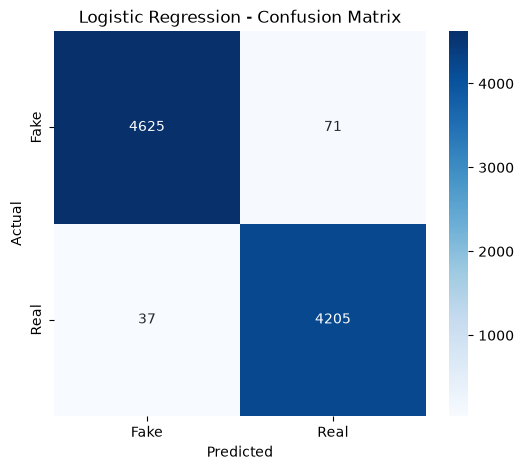

In [82]:
plt.figure(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Fake", "Real"],
    yticklabels=["Fake", "Real"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Logistic Regression - Confusion Matrix")
plt.show()

In [83]:
from sklearn.naive_bayes import MultinomialNB
nb = MultinomialNB()
nb.fit(X_train_tfidf, y_train)
y_pred_nb = nb.predict(X_test_tfidf)

In [84]:
print("Accuracy :", accuracy_score(y_test, y_pred_nb))
print("Precision:", precision_score(y_test, y_pred_nb))
print("Recall   :", recall_score(y_test, y_pred_nb))
print("F1 Score :", f1_score(y_test, y_pred_nb))

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred_nb))

Accuracy : 0.9390243902439024
Precision: 0.9416965352449224
Recall   : 0.929042904290429
F1 Score : 0.9353269253589652

Classification Report:

              precision    recall  f1-score   support

           0       0.94      0.95      0.94      4696
           1       0.94      0.93      0.94      4242

    accuracy                           0.94      8938
   macro avg       0.94      0.94      0.94      8938
weighted avg       0.94      0.94      0.94      8938



In [85]:
cm_nb = confusion_matrix(y_test, y_pred_nb)

print(cm_nb)

[[4452  244]
 [ 301 3941]]


In [86]:
from sklearn.svm import LinearSVC
svm = LinearSVC(
    random_state=42
)
svm.fit(X_train_tfidf, y_train)
y_pred_svm = svm.predict(X_test_tfidf)

In [87]:
print("Accuracy :", accuracy_score(y_test, y_pred_svm))
print("Precision:", precision_score(y_test, y_pred_svm))
print("Recall   :", recall_score(y_test, y_pred_svm))
print("F1 Score :", f1_score(y_test, y_pred_svm))

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred_svm))

Accuracy : 0.9958603714477512
Precision: 0.9955220362950742
Recall   : 0.9957567185289957
F1 Score : 0.9956393635827931

Classification Report:

              precision    recall  f1-score   support

           0       1.00      1.00      1.00      4696
           1       1.00      1.00      1.00      4242

    accuracy                           1.00      8938
   macro avg       1.00      1.00      1.00      8938
weighted avg       1.00      1.00      1.00      8938



In [88]:
cm_svm = confusion_matrix(y_test, y_pred_svm)

print(cm_svm)

[[4677   19]
 [  18 4224]]


In [89]:
wrong_indices = X_test.index[y_test != y_pred_svm]

print("Wrong predictions:", len(wrong_indices))

Wrong predictions: 37


In [90]:
errors = df.loc[wrong_indices, [
    "title",
    "text",
    "label"
]].copy()

errors["predicted"] = y_pred_svm[y_test != y_pred_svm]

print(errors.head(10))

                                                   title  \
14459  North Korea warns states: Don't join any U.S. ...   
22891                     Graphic: Supreme Court roundup   
16129  BREAKING: NORTH KOREA Detains American Student...   
39381    Obama drinks coconut water to cool down in Laos   
32151  WHAT IF The Presidential Race Was A NASCAR Event?   
7366   Hacked emails show Clinton aides surprised at ...   
24310       Mosley would have kept Ecclestone at F1 helm   
23560  JUST IN: Senior GOP Rep Announces His Retireme...   
42359  UK's Daily Mail to pay Melania Trump damages o...   
16195  Trump draws full house at own event as he snub...   

                                                    text  label  predicted  
14459  UNITED NATIONS (Reuters) - North Korea warned ...      1          0  
22891                                                         1          0  
16129  Apparently it takes just one American student ...      0          1  
39381  U.S. President Barack Ob

In [91]:
errors[["title", "label", "predicted"]]

,title,label,predicted
14459,North Korea warns states: Don't join any U.S. ...,1,0
22891,Graphic: Supreme Court roundup,1,0
16129,BREAKING: NORTH KOREA Detains American Student...,0,1
39381,Obama drinks coconut water to cool down in Laos,1,0
32151,WHAT IF The Presidential Race Was A NASCAR Event?,0,1
7366,Hacked emails show Clinton aides surprised at ...,1,0
24310,Mosley would have kept Ecclestone at F1 helm,1,0
23560,JUST IN: Senior GOP Rep Announces His Retireme...,0,1
42359,UK's Daily Mail to pay Melania Trump damages o...,1,0
16195,Trump draws full house at own event as he snub...,1,0


In [92]:
errors["correct"] = errors["label"] == errors["predicted"]

print(errors["correct"].value_counts())

correct
False    37
Name: count, dtype: int64


In [93]:
print(errors[["title", "label", "predicted"]].to_string(index=False))

                                                                                                                    title  label  predicted
                                                     North Korea warns states: Don't join any U.S. action and you're safe      1          0
                                                                                           Graphic: Supreme Court roundup      1          0
                                                         BREAKING: NORTH KOREA Detains American Student For “Hostile Act”      0          1
                                                                          Obama drinks coconut water to cool down in Laos      1          0
                                                                        WHAT IF The Presidential Race Was A NASCAR Event?      0          1
                                                     Hacked emails show Clinton aides surprised at 2015 email revelations      1          0
                    

In [94]:
print("Fake → Real:", ((y_test == 0) & (y_pred_svm == 1)).sum())
print("Real → Fake:", ((y_test == 1) & (y_pred_svm == 0)).sum())

Fake → Real: 19
Real → Fake: 18


In [95]:
duplicate_titles = df[df["title"].duplicated(keep=False)].sort_values("title")

print("Rows with duplicate titles:",
      len(duplicate_titles))

print(
    duplicate_titles[
        ["title", "label"]
    ].head(20).to_string(index=False)
)

Rows with duplicate titles: 11405
                                                                                                                                          title  label
                                                                McConnell Says He’ll Obstruct ANY Effort To Hire Independent Special Prosecutor      0
                                                                McConnell Says He’ll Obstruct ANY Effort To Hire Independent Special Prosecutor      0
      #AnyoneButHillary: NEW POLL Shows Bernie Supporters WON’T Vote For Hillary…Who They’ll Vote For If Hillary’s The Nominee May Surprise You      0
      #AnyoneButHillary: NEW POLL Shows Bernie Supporters WON’T Vote For Hillary…Who They’ll Vote For If Hillary’s The Nominee May Surprise You      0
                                                                             #Austin: Fights Break Out Between Police and Soros Commies [Video]      0
                                                            

In [96]:
df[df["title"].str.contains(
    "ARIZONA BIKERS",
    case=False,
    na=False
)][["title", "text", "label"]]

,title,text,label
428,ARIZONA BIKERS ARE ABOUT To Become Violent “Dr...,The Left has been itching for a fight the onl...,0
28470,ARIZONA BIKERS ARE ABOUT To Become Violent “Dr...,The Left has been itching for a fight the onl...,0


In [97]:
df[df["title"].str.contains(
    "PHILIPPINES: 2016",
    case=False,
    na=False
)][["title", "text", "label"]]

,title,text,label
14416,PHILIPPINES: 2016 Washington’s Fury as Philipp...,Duterte takes clear lead in Philippine electi...,0
39438,PHILIPPINES: 2016 Washington’s Fury as Philipp...,Duterte takes clear lead in Philippine electi...,0


In [98]:
print("Exact duplicate rows:",
      df.duplicated(subset=["title", "text"]).sum())

Exact duplicate rows: 5584


In [99]:
df_clean = df.drop_duplicates(
    subset=["title", "text"],
    keep="first"
).copy()

In [100]:
print("Before:", len(df))
print("After :", len(df_clean))
print("Removed:", len(df) - len(df_clean))

Before: 44689
After : 39105
Removed: 5584


In [101]:
df_clean.reset_index(drop=True, inplace=True)

In [102]:
X = df_clean["model_text"]
y = df_clean["label"]

In [103]:
print(X.shape)
print(y.shape)
print(y.value_counts())

(39105,)
(39105,)
label
1    21197
0    17908
Name: count, dtype: int64


In [104]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("X_train:", X_train.shape)
print("X_test :", X_test.shape)

X_train: (31284,)
X_test : (7821,)


In [105]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(
    max_features=50000
)

X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

print("X_train TF-IDF:", X_train_tfidf.shape)
print("X_test TF-IDF :", X_test_tfidf.shape)

X_train TF-IDF: (31284, 50000)
X_test TF-IDF : (7821, 50000)


In [106]:
from sklearn.svm import LinearSVC

svm = LinearSVC(random_state=42)

svm.fit(X_train_tfidf, y_train)

y_pred_svm = svm.predict(X_test_tfidf)

In [107]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

print("Accuracy :", accuracy_score(y_test, y_pred_svm))
print("Precision:", precision_score(y_test, y_pred_svm))
print("Recall   :", recall_score(y_test, y_pred_svm))
print("F1 Score :", f1_score(y_test, y_pred_svm))

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred_svm))

print("\nConfusion Matrix:\n")
print(confusion_matrix(y_test, y_pred_svm))

Accuracy : 0.9928397903081447
Precision: 0.991539365452409
Recall   : 0.9952819061099316
F1 Score : 0.993407110901813

Classification Report:

              precision    recall  f1-score   support

           0       0.99      0.99      0.99      3582
           1       0.99      1.00      0.99      4239

    accuracy                           0.99      7821
   macro avg       0.99      0.99      0.99      7821
weighted avg       0.99      0.99      0.99      7821


Confusion Matrix:

[[3546   36]
 [  20 4219]]


In [108]:
duplicate_titles_clean = df_clean[
    df_clean["title"].duplicated(keep=False)
].sort_values("title")

print(
    "Rows with duplicate titles after cleaning:",
    len(duplicate_titles_clean)
)

Rows with duplicate titles after cleaning: 716


In [109]:
print(
    duplicate_titles_clean[
        ["title", "label"]
    ].head(30).to_string(index=False)
)

                                                                             title  label
   McConnell Says He’ll Obstruct ANY Effort To Hire Independent Special Prosecutor      0
   McConnell Says He’ll Obstruct ANY Effort To Hire Independent Special Prosecutor      0
'Can I get it to go?' Canada's Trudeau charms  Manila while ordering fried chicken      1
'Can I get it to go?' Canada's Trudeau charms  Manila while ordering fried chicken      1
               'Fierce and formidable' Dlamini-Zuma eyes South Africa's presidency      1
               'Fierce and formidable' Dlamini-Zuma eyes South Africa's presidency      1
                     'Fully committed' NATO backs new U.S. approach on Afghanistan      1
                     'Fully committed' NATO backs new U.S. approach on Afghanistan      1
    'He's such a dreamer:' Skepticism dogs U.S. envoy's North Korean peace efforts      1
    'He's such a dreamer:' Skepticism dogs U.S. envoy's North Korean peace efforts      1
      'Tru

In [110]:
title_label_check = (
    df_clean.groupby("title")["label"]
    .nunique()
)

print(
    "Titles having different labels:",
    (title_label_check > 1).sum()
)

Titles having different labels: 0


In [111]:
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import LinearSVC
from sklearn.model_selection import cross_val_score

X = df_clean["model_text"]
y = df_clean["label"]

svm_pipeline = Pipeline([
    ("tfidf", TfidfVectorizer(max_features=50000)),
    ("svm", LinearSVC(random_state=42))
])

cv_scores = cross_val_score(
    svm_pipeline,
    X,
    y,
    cv=5,
    scoring="accuracy",
    n_jobs=-1
)

print("CV Scores:", cv_scores)
print("Mean CV Accuracy:", cv_scores.mean())
print("Std CV Accuracy:", cv_scores.std())

CV Scores: [0.99156118 0.99258407 0.99232835 0.99360696 0.99437412]
Mean CV Accuracy: 0.9928909346630865
Std CV Accuracy: 0.0009890847516079138


In [112]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    "svm__C": [0.1, 1, 10]
}

grid_search = GridSearchCV(
    svm_pipeline,
    param_grid,
    cv=3,
    scoring="accuracy",
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X, y)

print("Best Parameters:", grid_search.best_params_)
print("Best CV Accuracy:", grid_search.best_score_)

Fitting 3 folds for each of 3 candidates, totalling 9 fits
Best Parameters: {'svm__C': 1}
Best CV Accuracy: 0.9920214806290756


In [113]:
best_svm = grid_search.best_estimator_

print(best_svm)

Pipeline(steps=[('tfidf', TfidfVectorizer(max_features=50000)),
                ('svm', LinearSVC(C=1, random_state=42))])


In [114]:
y_pred_final = best_svm.predict(X_test)

In [115]:
print("Final Accuracy :", accuracy_score(y_test, y_pred_final))
print("Final Precision:", precision_score(y_test, y_pred_final))
print("Final Recall   :", recall_score(y_test, y_pred_final))
print("Final F1 Score :", f1_score(y_test, y_pred_final))
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred_final))
cm_final = confusion_matrix(y_test, y_pred_final)

print("\nConfusion Matrix:\n")
print(cm_final)

Final Accuracy : 0.9989771129011635
Final Precision: 0.998116317400518
Final Recall   : 1.0
Final F1 Score : 0.999057270798963

Classification Report:

              precision    recall  f1-score   support

           0       1.00      1.00      1.00      3582
           1       1.00      1.00      1.00      4239

    accuracy                           1.00      7821
   macro avg       1.00      1.00      1.00      7821
weighted avg       1.00      1.00      1.00      7821


Confusion Matrix:

[[3574    8]
 [   0 4239]]


In [116]:
train_titles = set(df_clean.loc[X_train.index, "title"])
test_titles = set(df_clean.loc[X_test.index, "title"])

overlap_titles = train_titles.intersection(test_titles)

print("Train titles:", len(train_titles))
print("Test titles :", len(test_titles))
print("Overlapping titles:", len(overlap_titles))

Train titles: 31017
Test titles : 7801
Overlapping titles: 89


In [117]:
train_articles = set(
    zip(
        df_clean.loc[X_train.index, "title"],
        df_clean.loc[X_train.index, "text"]
    )
)

test_articles = set(
    zip(
        df_clean.loc[X_test.index, "title"],
        df_clean.loc[X_test.index, "text"]
    )
)

overlap_articles = train_articles.intersection(test_articles)

print("Exact train-test article overlap:", len(overlap_articles))

Exact train-test article overlap: 0


In [119]:
overlap_title_df = df_clean[
    df_clean["title"].isin(overlap_titles)
][["title", "text", "label"]]

print(
    overlap_title_df
    .sort_values("title")
    .head(30)
    .to_string(index=False)
)


                                                                             title                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                      

In [120]:
print(
    overlap_title_df
    .groupby("title")["label"]
    .nunique()
    .value_counts()
)

label
1    89
Name: count, dtype: int64


In [121]:
from sklearn.model_selection import GroupShuffleSplit

gss = GroupShuffleSplit(
    n_splits=1,
    test_size=0.2,
    random_state=42
)

train_idx, test_idx = next(
    gss.split(
        df_clean["model_text"],
        df_clean["label"],
        groups=df_clean["title"]
    )
)

X_train_group = df_clean.iloc[train_idx]["model_text"]
X_test_group = df_clean.iloc[test_idx]["model_text"]

y_train_group = df_clean.iloc[train_idx]["label"]
y_test_group = df_clean.iloc[test_idx]["label"]

In [122]:
svm_group = Pipeline([
    ("tfidf", TfidfVectorizer(max_features=50000)),
    ("svm", LinearSVC(C=1, random_state=42))
])

svm_group.fit(X_train_group, y_train_group)

y_pred_group = svm_group.predict(X_test_group)

In [123]:
print("Accuracy :", accuracy_score(y_test_group, y_pred_group))
print("Precision:", precision_score(y_test_group, y_pred_group))
print("Recall   :", recall_score(y_test_group, y_pred_group))
print("F1 Score :", f1_score(y_test_group, y_pred_group))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test_group, y_pred_group))

Accuracy : 0.9927137926626614
Precision: 0.99265750828991
Recall   : 0.9938344794877876
F1 Score : 0.9932456452186278

Confusion Matrix:
[[3575   31]
 [  26 4191]]


In [124]:
wrong_group = y_test_group != y_pred_group

print("Wrong predictions:", wrong_group.sum())

errors_group = df_clean.iloc[test_idx][wrong_group].copy()

errors_group["predicted"] = y_pred_group[wrong_group]

print(
    errors_group[["title", "label", "predicted"]]
    .to_string(index=False)
)

Wrong predictions: 57
                                                                                                                                                                           title  label  predicted
                                                                                                                              Trump son-in-law Kushner's congressional statement      1          0
                                                                           ARIZONA BIKERS ARE ABOUT To Become Violent “Dreamers” Worst Nightmare At Upcoming Phoenix Trump Rally      0          1
                                       PALESTINIANS STEPPING UP STABBINGS: Dramatic Video Shows Palestinian Man Stabbing Israeli Police Officers…Israeli Teen Stabbed On Bicycle      0          1
                                                                                                                                   Zach Johnson, Pieters share lead at Firestone      1          0
   

In [125]:
print(
    "Fake → Real:",
    ((y_test_group == 0) & (y_pred_group == 1)).sum()
)

print(
    "Real → Fake:",
    ((y_test_group == 1) & (y_pred_group == 0)).sum()
)

Fake → Real: 31
Real → Fake: 26


In [126]:
def predict_news(title, text):
    combined_text = title + " " + text
    
    prediction = svm_group.predict([combined_text])[0]
    
    if prediction == 0:
        return "FAKE NEWS"
    else:
        return "REAL NEWS"

In [127]:
title = "Trump announces new policy"
text = "The president announced a new policy during a press conference."

print(predict_news(title, text))

FAKE NEWS


In [128]:
def preprocess_for_prediction(text):
    text = text.lower()
    
    # Tokenization
    tokens = word_tokenize(text)
    
    # Stopword removal
    tokens = [
        word for word in tokens
        if word not in stop_words and word.isalpha()
    ]
    
    # Lemmatization
    tokens = [
        lemmatizer.lemmatize(word, pos="v")
        for word in tokens
    ]
    
    return " ".join(tokens)

In [129]:
def predict_news(title, text):
    combined_text = title + " " + text
    
    cleaned_text = preprocess_for_prediction(combined_text)
    
    prediction = svm_group.predict([cleaned_text])[0]
    
    if prediction == 0:
        return "FAKE NEWS"
    else:
        return "REAL NEWS"

In [130]:
title = "Trump announces new policy"

text = "The president announced a new policy during a press conference."

print(predict_news(title, text))

FAKE NEWS


In [131]:
title = "U.S. President announces new economic policy"

text = """
The president announced a new economic policy during a press conference
on Tuesday. Government officials said the policy will focus on employment,
economic growth and supporting small businesses.
"""

print(predict_news(title, text))

FAKE NEWS


In [132]:
title = "SHOCKING! President reveals unbelievable secret plan"

text = """
The president has secretly planned a massive change that will completely
transform the country. Sources claim that this shocking plan will be
announced very soon and everyone will be stunned.
"""

print(predict_news(title, text))

FAKE NEWS


In [133]:
def predict_news(title, text):
    combined_text = title + " " + text

    cleaned_text = preprocess_for_prediction(combined_text)

    prediction = svm_group.predict([cleaned_text])[0]
    score = svm_group.decision_function([cleaned_text])[0]

    if prediction == 0:
        result = "FAKE NEWS"
    else:
        result = "REAL NEWS"

    return result, score

In [134]:
title = "SHOCKING! President reveals unbelievable secret plan"

text = """
The president has secretly planned a massive change that will completely
transform the country. Sources claim that this shocking plan will be
announced very soon and everyone will be stunned.
"""

result, score = predict_news(title, text)

print("Prediction:", result)
print("Decision Score:", score)

Prediction: FAKE NEWS
Decision Score: -1.2109287334056273


In [135]:
import joblib

joblib.dump(svm_group, "fake_news_svm_pipeline.pkl")

print("Model saved successfully!")

Model saved successfully!


In [136]:
import os

print(os.path.exists("fake_news_svm_pipeline.pkl"))

True


In [137]:
loaded_model = joblib.load("fake_news_svm_pipeline.pkl")

print("Model loaded successfully!")

Model loaded successfully!


In [138]:
title = "SHOCKING! President reveals unbelievable secret plan"

text = """
The president has secretly planned a massive change that will completely
transform the country. Sources claim that this shocking plan will be
announced very soon and everyone will be stunned.
"""

combined_text = title + " " + text

prediction = loaded_model.predict([combined_text])[0]

if prediction == 0:
    print("Prediction: FAKE NEWS")
else:
    print("Prediction: REAL NEWS")

Prediction: FAKE NEWS
